## Model Training Challenge!

In this notebook, there are a whole host of weird errors.
Some of them will be obvious and throw an error, but some are less clear and will break things without telling you they're breaking.
Do your best to sniff out the mistakes in both code and training procedure!

Your mission, should you choose to accept it, is:
* Work together in groups of 4 to complete this notebook
* Figure out all the coding mistakes and make a notebook that runs
* Find the mistakes in training and take appropriate corrective measures so the model trains well!
* Make a ~15 minute long presentation showing your results and the steps you took to find and solve them.

This line below installs a non-standard data generation package.
It is designed to make images for benchmarking computer vision problems, and is the back bone of your generator.
Unfortunately, it's not included with colab (which makes sense....), so we have to install it.
The `!` point here means "Execute this line like it's a line in a bash prompt".

In [1]:
! pip install deepbench

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 18.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: tifffile
    Found existing installation: tifffile 2026.4.11
    Uninstalling tifffile-2026.4.11:
      Successfully uninstalled tifffile-2026.4.11
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.25.2
    Uninstalling scikit-image-0.25.2:
      Suc

`curl` is a package for downloading files off the internet.
This below line just downloads a file form the repo into this colab instance, and names it "challenge_utilities.py".
This file is also in the github repo, you can look at it there if you want.
It contains the data generator for each for your challenges, and the utilities for plotting and evaluating results.
(It won't contain any problems for you to solve, it's just there to keep this notebook from getting cluttered.)

In [ ]:
! curl -o challenge_utilities.py https://raw.githubusercontent.com/BNL-Fermilab-RENEW/tutorials/refs/heads/main/Challenge/challenge_utilities.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  7248  100  7248    0     0  54291      0 --:--:-- --:--:-- --:--:--     0--:-- --:--:-- --:--:-- 54496


In [1]:
# Now we'll import the different classes from this new file
# Import the dataloader and dataset classes
from challenge_utilities import SkyDataset # Dataset object itself
# A subclass of torch.utils.data.Dataset
from challenge_utilities import SkyGenerator # Generic dataloader object, same for all challenges
from challenge_utilities import Eval

In [2]:
# Standard packages
import matplotlib.pyplot as plt

import torch
import torchvision
from torchsummary import summary

#### Package documentation

If you get stuck for syntax or anything - these are the packages used.
Look up a function you're trying to use in their package search pages, and see if you maybe have types wrong, or wrong variable names.

[MatPlotLib](https://matplotlib.org/)

[Pytorch](https://docs.pytorch.org/docs/)


# Exploratory Data Analysis

Understanding your data is a critical part of any AI/ML project.
Make sure you look at your data and understand the differences between each class.

Something to note, which you would only know if you gathered the data yourself, is that the binary "0" and "1" labels correspond to "stars" and "galaxies".
You can use this to label your plots.

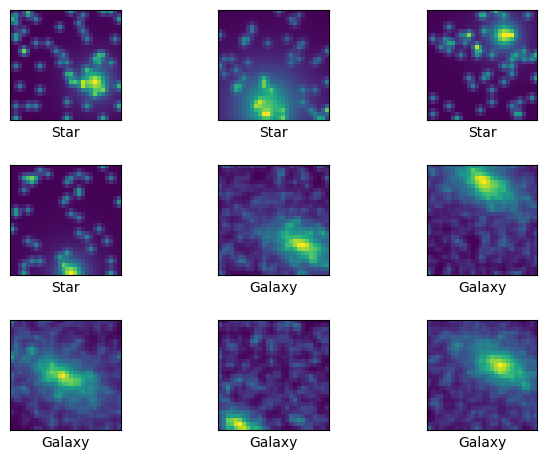

In [3]:

label_map = {
    0: "Star",
    1: "Galaxy"
}

def plot_samples(generator, n_columns=3, n_rows=3, label_map:dict|None=None):
    _, subplots = plt.subplots(n_columns, n_rows) # Make 9 plots in a 3 x 3 grid
    plt.tight_layout()
    plt.setp(subplots, xticks=[], yticks=[])

    for sample_index, subplot in zip(range(n_columns*n_rows), subplots.ravel()):
        image, label = generator.get(sample_index)
        subplot.imshow(image.squeeze())
        # 'imshow' displays an image in 2d (black and white if it only has 1 color channel, or in color if it has 3 (r,g,b) color channels).
        # Here it's green and blue because the default colorway for matplotlib is "viridis", with is all cool colors

        string_label = label_map[label.item()] if label_map else str(label.item())
        subplot.set_xlabel(string_label) # This gives you a label underneath the image (on the x axis)

samples = SkyDataset(n_samples=9, seed=42) # Can just get a few samples
plot_samples(samples, label_map=label_map)

# Look at the input data

Understanding the data is a critical part of the training process, let's take a look at the distributions we're working with.

In [4]:
# These two generators produce the data we'll train with

n_train_samples = 1280
train_generator = SkyGenerator(n_samples=n_train_samples,  dataset=SkyDataset, shuffle=True)

n_val_samples = 1280
val_generator = SkyGenerator(n_samples=n_val_samples, dataset=SkyDataset, shuffle=True)

Text(0.5, 1.0, 'Val labels')

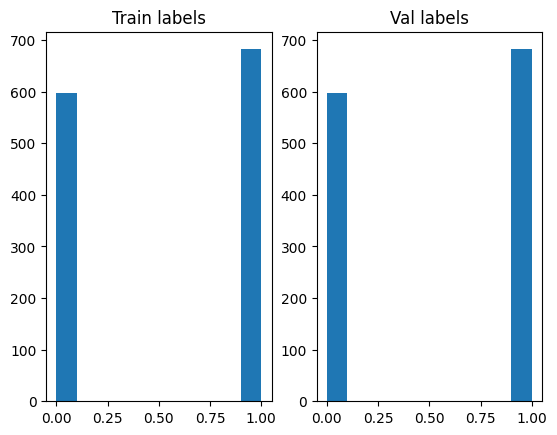

In [5]:
# Each dataset object has a "labels" and "images" attribute, which we can use to check out the data range

fig, ax = plt.subplots(1,2)
ax[0].hist(train_generator.dataset.labels)
ax[0].set_title("Train labels")
ax[1].hist(val_generator.dataset.labels)
ax[1].set_title("Val labels")



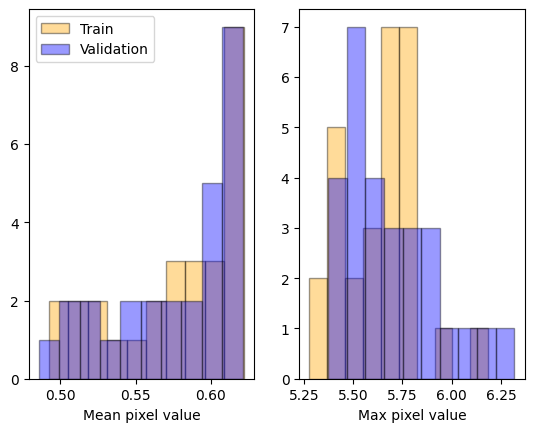

In [6]:
# We can also look at different attributes of the images
# Here, let's look at max values and mean values

# These numbers will be slightly different every time, there's randomness controlling how the images are generated
# In scientific settings, it's good to remove the randomness if possible, but here it's fine

# Normally we would also have some metadata to work with, but here we only have images

train_means = train_generator.dataset.images.mean(axis=(1, 0))

val_means = val_generator.dataset.images.mean(axis=(1, 0))

figure, subplots = plt.subplots(1, 2)
subplots[0].hist(train_means, color="orange", edgecolor="black", label="Train", alpha=0.4)
subplots[0].hist(val_means,  color="blue", edgecolor="black", label="Validation", alpha=0.4)
subplots[0].legend()
subplots[0].set_xlabel("Mean pixel value")

train_maxes = train_generator.dataset.images.max(axis=(1, 0))
val_maxes = val_generator.dataset.images.max(axis=(1, 0))
subplots[1].hist(train_maxes, color="orange", edgecolor="black", label="Train", alpha=0.4)
subplots[1].hist(val_maxes,  color="blue", edgecolor="black", label="Validation", alpha=0.4)
subplots[1].set_xlabel("Max pixel value")


plt.show()

## Data Processing

There are many ways to help a model along when it comes to training - one of those is data pre-processing.
There are near infinite ways to pre-process, especially in the computer vision space.
Think about it like applying different instagram filters, they have different impacts that emphasis the image in different ways.

For this, let's try bringing all the pixels in the image between 0 and 1.

In [9]:
# Torch uses "transforms" to apply a series of transforms to the data as its being loaded
# We can define this as a set of transforms we can apply either as part of the dataloader,
# or as a separate step after loading the data.

transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize((64, 64)), # Resize the images to 64 x 64 pixels
    torchvision.transforms.Normalize(0.5, 0.5) # Normalize the pixel values to be between 0 and 1
])

# We can apply other transforms, in a process called "data augmentation"
# It helps make the model less likely to overfit by giving it different versions of the same data during the training process
# All transforms can be seen here - https://docs.pytorch.org/vision/0.26/transforms.html#v2-api-reference-recommended


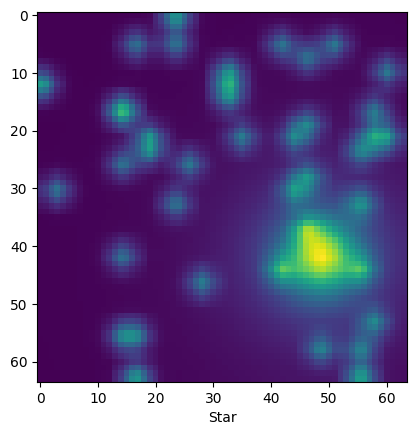

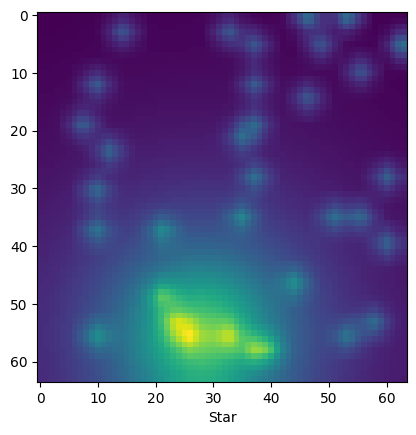

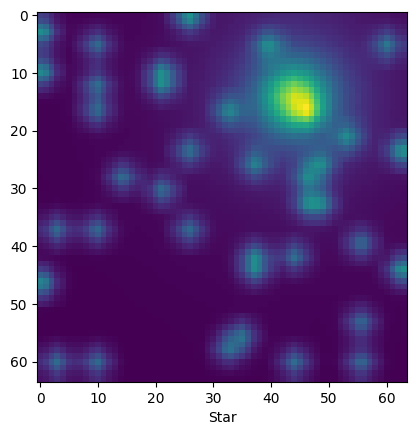

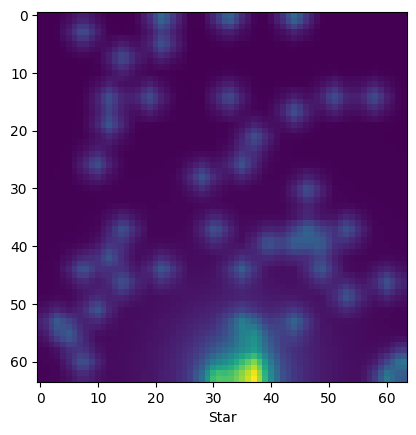

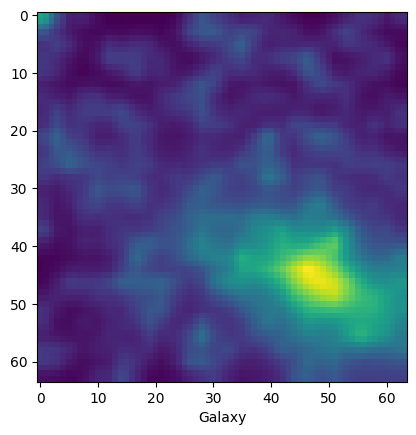

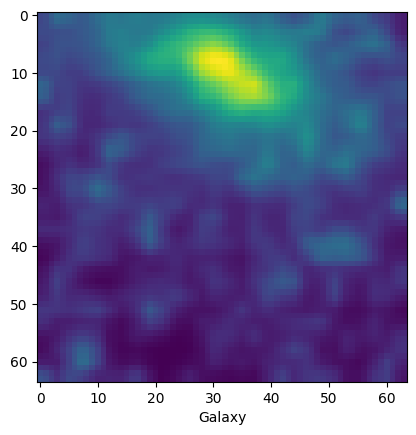

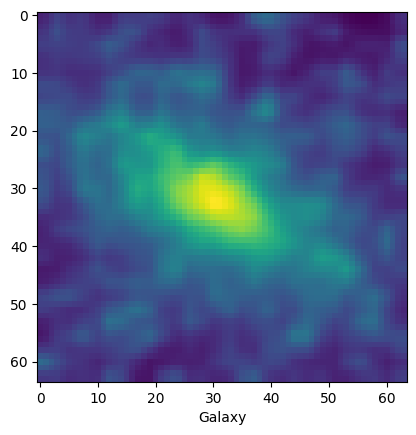

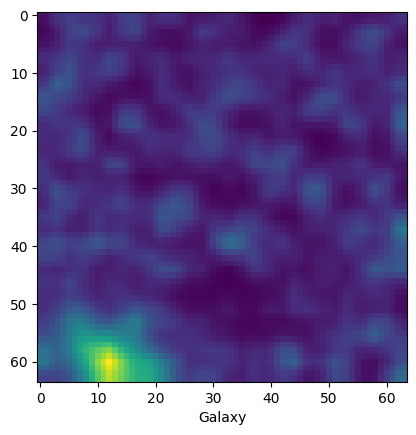

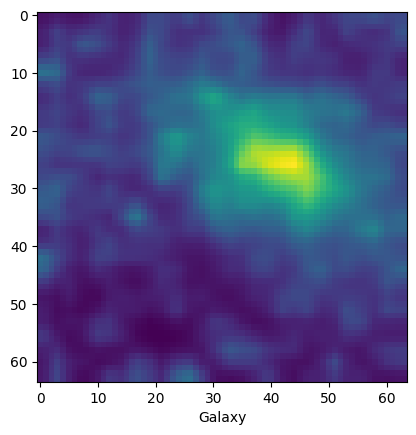

In [13]:
# Look at some processed samples!

n_samples = 9
samples = SkyGenerator(n_samples=n_samples, batch_size=1, dataset=SkyDataset).get_dataloader()
for image, label in samples:
    image = transforms(image)
    plt.imshow(image[0][0]) # The image size is given as (batch, im channels, im_size, im_size)
    plt.xlabel(label_map[label.item()])
    plt.show()


## Make the binary classification model

This function, when called, produces a keras Model instance that you can train to predict a class of an input.
Because this is a binary predictor, it can be used to pick if an image is closer to being class 0 or class 1.
It takes an input of a certain shape, (defined by the `in_layer`), fits it to a convolution operation, and gives you a number (or array!) back out.
The way this becomes a predictive engine is through the loss, of the output of the model will minimize a loss function, and give us a prediction that matches the data we fed it.

In this case, what we want:
* Take the input images from the data generator
* Apply two convolutional blocks to the input image
* Decode the second convolution block's output to a probability of the image being a given class.

In [40]:
# Create a simple convolusional model

class SimpleCNN(torch.nn.Module):
    def __init__(self):
      super().__init__()
      self.conv1 = torch.nn.Conv2d(1, 16, kernel_size=3, padding=1)
      self.conv2 = torch.nn.Conv2d(16, 32, kernel_size=3, padding=1)
      self.conv3 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)

      # Pooling layer
      self.pool = torch.nn.MaxPool2d(2, 2)

      # Fully connected layers
      # After 3 pooling layers: 64 -> 32 -> 16 -> 8, so feature map is 8x8
      # 64 channels * 8x8 = 4096 input features
      self.fc1 = torch.nn.Linear(64 * 8 * 8, 128)
      self.fc2 = torch.nn.Linear(128, 1)

      # Dropout
      self.dropout = torch.nn.Dropout(0.3)

      # Activation
      self.relu = torch.nn.ReLU()

    def forward(self, x):
      # Input: (batch_size, 64, 64) - need to add channel dimension
      if x.dim() == 3:
          x = x.unsqueeze(1)  # Now (batch_size, 1, 64, 64)

      # Conv block 1: (batch_size, 1, 64, 64) -> (batch_size, 16, 32, 32)
      x = self.pool(self.relu(self.conv1(x)))

      # Conv block 2: (batch_size, 16, 32, 32) -> (batch_size, 32, 16, 16)
      x = self.pool(self.relu(self.conv2(x)))

      # Conv block 3: (batch_size, 32, 16, 16) -> (batch_size, 64, 8, 8)
      x = self.pool(self.relu(self.conv3(x)))

      # Flatten: (batch_size, 64*8*8) = (batch_size, 4096)
      x = x.view(x.size(0), -1)

      # Fully connected layers
      x = self.relu(self.fc1(x))
      x = self.dropout(x)
      x = self.fc2(x)  # Output: (batch_size, 1)

      return torch.softmax(x.squeeze(), 0) # Output of (batch_size)

print(summary(SimpleCNN(), input_size=(1, 64, 64)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             160
              ReLU-2           [-1, 16, 64, 64]               0
         MaxPool2d-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           4,640
              ReLU-5           [-1, 32, 32, 32]               0
         MaxPool2d-6           [-1, 32, 16, 16]               0
            Conv2d-7           [-1, 64, 16, 16]          18,496
              ReLU-8           [-1, 64, 16, 16]               0
         MaxPool2d-9             [-1, 64, 8, 8]               0
           Linear-10                  [-1, 128]         524,416
             ReLU-11                  [-1, 128]               0
          Dropout-12                  [-1, 128]               0
           Linear-13                    [-1, 1]             129
Total params: 547,841
Trainable params:

## Training process

Based on the previous lessons, we know we need a few things to train a model

### Loss and Optimizer


### Training and Validation data loops



In [31]:
# Random choices of optimizer and loss functions
# These are pretty standard for classification
optimizer = torch.optim.Adam(SimpleCNN().parameters(), lr=0.001)
criterion = torch.nn.BCELoss()  # BCE = Binary Cross Entropy (for 2 classes)



# Train the model

We have all the pieces in place:
- [x] Model
- [x] Train Data
- [x] Validation Data
- [x] Loss Function
- [x] Optimizer

In [43]:

def train_epoch(model, dataloader, optimizer, criterion):
    """Trains the model for a single epoch (one loop through the entire training dataset)"""
    batch_loss = torch.tensor(0.0) # Initialize the batch loss to 0
    n_batches = len(dataloader)
    for images, labels in dataloader:
      optimizer.zero_grad() # Clear the gradients from the previous step
      outputs = model(transforms(images)) # Forward pass: compute the model output for the current batch of images
      loss = criterion(outputs.to(float), labels.to(float)) # Compute the loss between the model output and the true labels
      loss.backward() # Backward pass: compute the gradients of the loss with respect to the model parameters
      optimizer.step() # Update the model parameters using the computed gradients
      batch_loss += loss.item() # Accumulate the loss for this batch

    return model, batch_loss.item() / n_batches # Return the average loss for this epoch


def val_epoch(model, dataloader, criterion):
    """Evaluates the model on the validation set for a single epoch (one loop through the entire validation dataset)"""
    batch_loss = torch.tensor(0.0) # Initialize the batch loss to 0
    n_batches = len(dataloader)
    with torch.no_grad(): # Disable gradient computation for validation
        for images, labels in dataloader:
            outputs = model(transforms(images)) # Forward pass: compute the model output for the current batch of images
            loss = criterion(outputs.to(float), labels.to(float)) # Compute the loss between the model output and the true labels
            batch_loss += loss.item() # Accumulate the loss for this batch

    return model, batch_loss.item() / n_batches # Return the average loss for this epoch


n_epochs = 10
model = SimpleCNN()
loss_history = {"train": [], "val": []}
for epoch in range(n_epochs):
    model, train_loss = train_epoch(model, train_generator.get_dataloader(), optimizer, criterion)
    model, val_loss = val_epoch(model, val_generator.get_dataloader(), criterion)
    loss_history["train"].append(train_loss)
    loss_history["val"].append(val_loss)



## Model Evaluation

There are some steps we can take to see how well a model trained.

### Loss Plots
Obvious one is to see how the loss progressed - if the loss was still trending down when the training stopped, it would make sense that the model would benefit from longer training.
Or, if the loss never moves or blows up entirely, that's a sign there's a problem.
Looking at the [common pitfalls notebook](https://github.com/BNL-Fermilab-RENEW/tutorials_2024/blob/main/07_Challenge/common_pitfalls.ipynb) may help diagnose your problems!

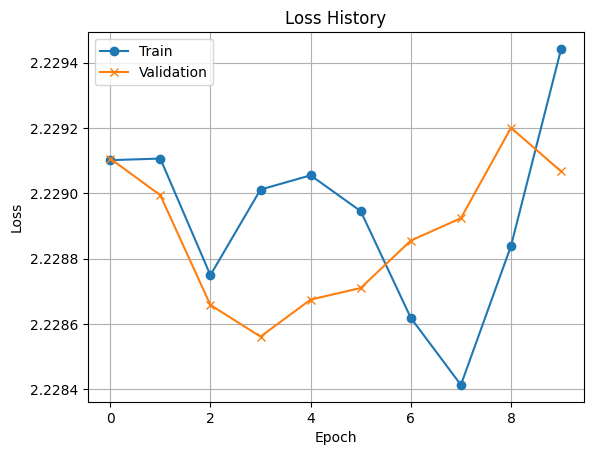

In [44]:
Eval.plot_loss_history(loss_history['train'], loss_history['val'])
# Eval.plot_history is a simple function
# plots the loss as a function of epoch

## Classification Accuracy Plots

After we did all this work to train a model, we need to be able to report how good it is on data we didn't use in training.
For this, we'll make a new set of data (or use some data we held out from training), and run a few evaluation metrics on it.

### ROC
The `receiver operating characteristic curve` (or just "ROC" (pronounced "Rock") Curve) is a metric that plots the true positive rate against the false positive rate.
It shows how likely a model is to correctly predict something.
The idea is that a classifier a better classifier will have lower false positive rate, and a higher true positive rate, so the curve will get closer and closer to the upper left corner as the prediction improves.


### Confusion Matrix

Confusion matrices are a great tool for seeing how well each class does against each other.
It gets it name from its ability to tell if a model is "confusing" two different classes.
It plots the rate of predicted values for a given class versus the true values.

 A good confusion matrix will have very high values in the green boxes, and lower values in the red boxes.

In [46]:
test_generator = SkyGenerator(n_samples=1280, dataset=SkyDataset, shuffle=True, transform=transforms)

def make_prediction(model, test_generator):
    prediction_classes = []
    for images, _ in test_generator.get_dataloader():
        predictions = model(transforms(images))
        prediction_classes += torch.where(predictions<0.5, 0, 1)
    labels = test_generator.dataset.labels


    return prediction_classes, labels

def test_quality(prediction, labels):
    accuracy = torch.mean((prediction == labels).float()) # Compute the accuracy by comparing the predicted classes to the true labels
    return accuracy.numpy()

prediction, labels = make_prediction(model, test_generator)
print(f"The binary classification accuracy on the test set is: {test_quality(prediction, labels)}")

AttributeError: 'numpy.ndarray' object has no attribute 'float'

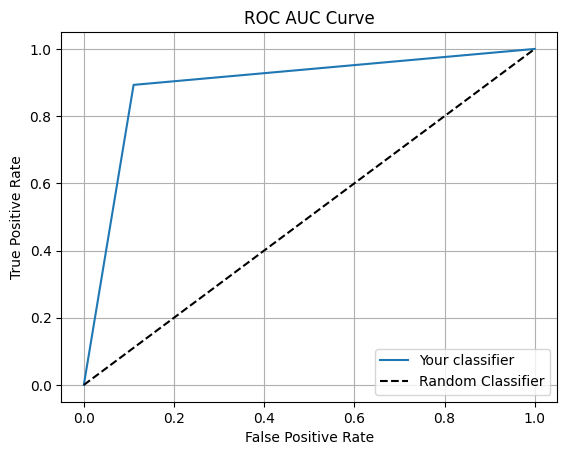

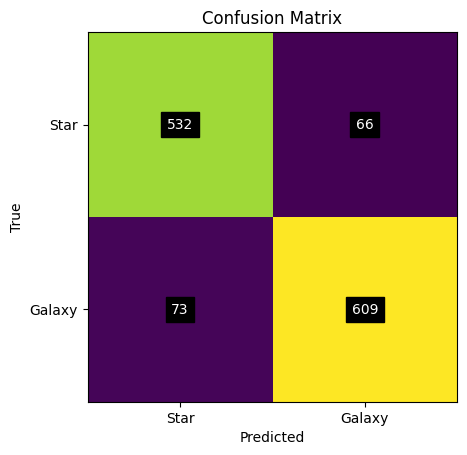

In [ ]:
# And now run them on your own data!
Eval.ROC_curve(prediction, labels)
Eval.confusion_matrix(prediction, labels)